# Umbral Global - Umbral Isodata

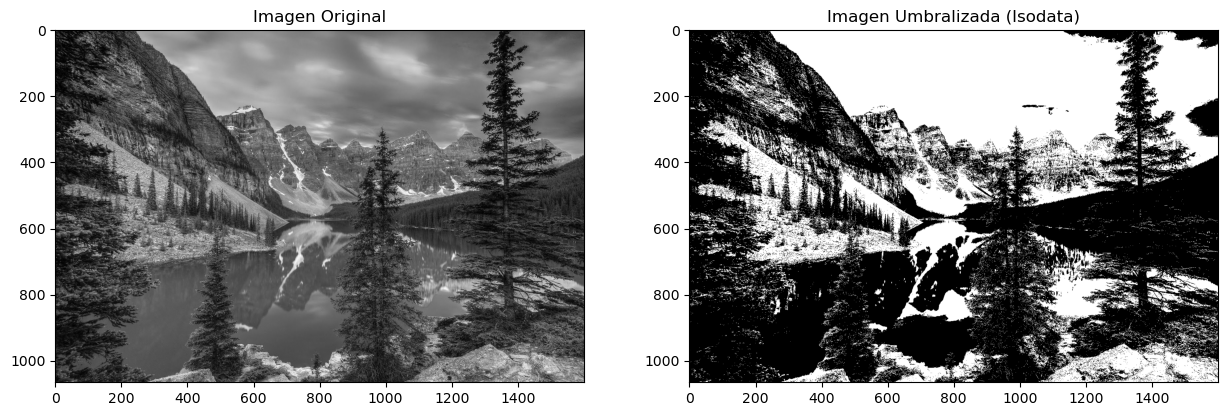

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def isodata(imagen):
    #decidimos umbral inicial de 0 a 255
    umbral = 128 #puedo cambiarlo cuando se requiera
    while True:
        grupo1 = imagen[imagen<=umbral] #grupo dende el umbral es menor o igual al valor determinado
        grupo2 = imagen[imagen > umbral] #mayor o igual al determinado
        
        #calculamos las medias de cada grupo
        media1 = np.mean(grupo1)
        media2 = np.mean(grupo2) 
        
        #calculamos el nuevo umbral
        nuevo_umbral = (media1 + media2) / 2
        
        #si el nuevo umbral es igual al anterior, terminamos
        if abs(nuevo_umbral - umbral) < 0.5: 
            break
        
        umbral = nuevo_umbral
    return umbral
imagen = cv2.imread('imagen.jpg', 0) #cargamos la imagen en escala de grises
umbral_isodata = isodata(imagen)
_,umbralizacion_iso=cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')
plt.subplot(1,2,2)
plt.title('Imagen Umbralizada (Isodata)')
plt.imshow(umbralizacion_iso, cmap='gray')

plt.show()

# Umbral Dos Picos

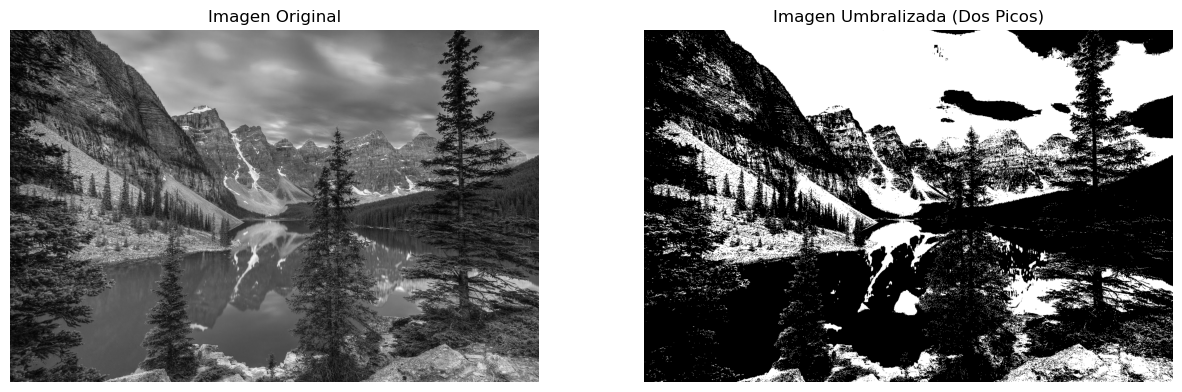

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(imagen):
    histograma = cv2.calcHist([imagen], [0], None, [256], [0, 256])
    
    pico = np.array(histograma)
    pico = pico.flatten()
    
    pico_dif = np.diff(pico)
    
    primer_pico = np.argmax(pico_dif[:128])
    segundo_pico = np.argmax(pico_dif[128:]) + 128
    
    umbral = int((primer_pico + segundo_pico) / 2)
    return umbral

imagen = cv2.imread('imagen.jpg', 0)

umbral_dos_picos = dos_picos(imagen)

_, nueva = cv2.threshold(imagen, int(umbral_dos_picos), 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Imagen Umbralizada (Dos Picos)')
plt.imshow(nueva, cmap='gray')
plt.axis('off')

plt.show()

# Umbralización de OTSU

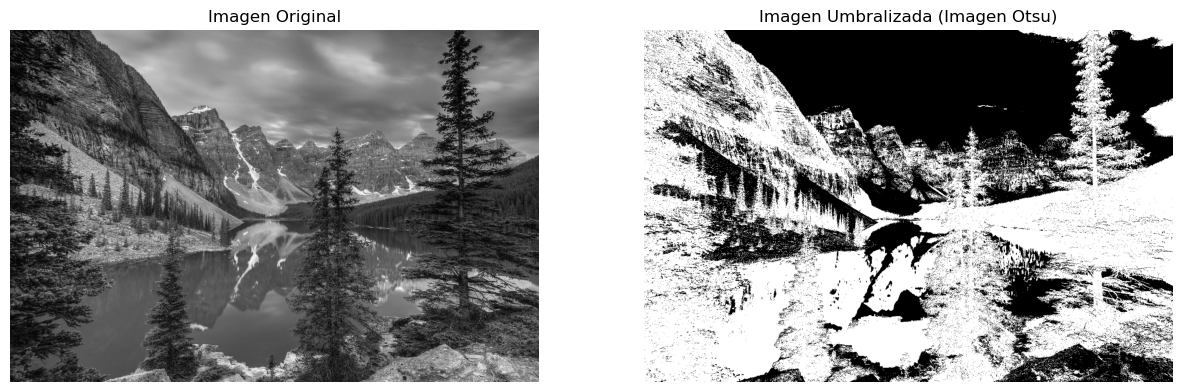

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen.jpg', 0) #escala de grises
_,otsu=cv2.threshold(imagen, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imagen_fin=np.where(imagen>otsu,255,0).astype(np.uint8)

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Imagen Umbralizada (Imagen Otsu)')
plt.imshow(imagen_fin, cmap='gray')
plt.axis('off')

plt.show()

# Umbralización variable partición de una imagen

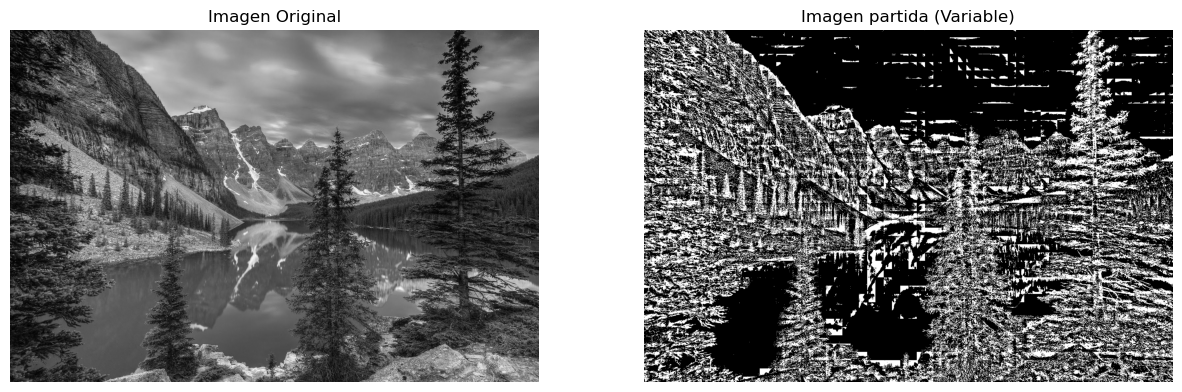

In [13]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
def variable_part(imagen,tam_bloque,c):
    umbral_img=np.zeros_like(imagen)
    for y in range(0, imagen.shape[0], tam_bloque): #recorremos filas
        for x in range(0, imagen.shape[1], tam_bloque): #recorremos columnas
            bloque = imagen[y:y+tam_bloque, x:x+tam_bloque] #extraemos el bloque de la imagen
            bloq_media = np.mean(bloque) #intensidad del bloque
            umbral = bloq_media - c 
            umbral_img[y:y+tam_bloque, x:x+tam_bloque] = (bloque > umbral)+255
    return umbral_img

tam_b=25
c=10
img=cv2.imread('imagen.jpg', 0)
img_fin=variable_part(img,tam_b,c)

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Imagen partida (Variable)')
plt.imshow(img_fin, cmap='gray')
plt.axis('off')

plt.show()

# Propiedades Locales

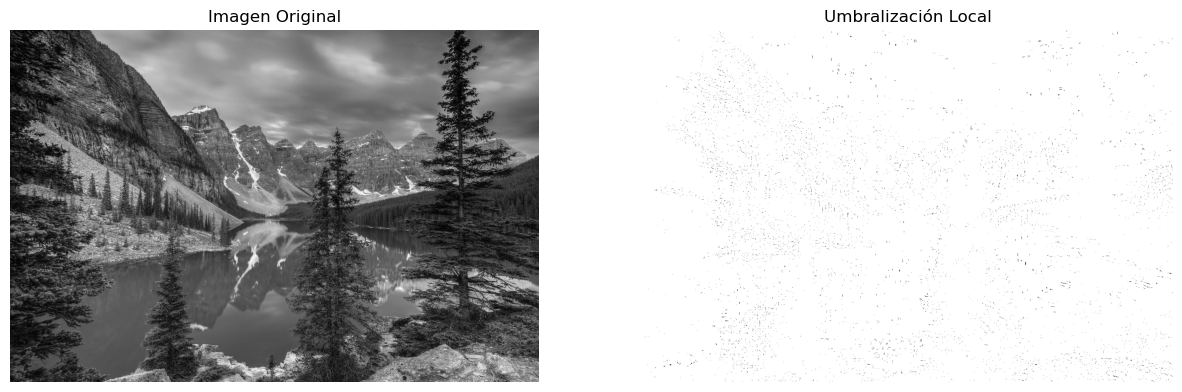

In [14]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
imagen = cv2.imread('imagen.jpg', 0)#escala de grises
def local(imagen,tamanio_ventana,k):
    umbr_img=np.zeros_like(imagen)
    #definir un rastreo de imagen con padding
    pad = tamanio_ventana // 2
    padded_image=cv2.copyMakeBorder(imagen, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    #recorremos cada pixel 
    for y in range(imagen.shape[0]):
        for x in range(imagen.shape[1]):
            ventana = padded_image[y:y+tamanio_ventana, x:x+tamanio_ventana]
            #calcullo de media y desviacion
            mean_local = np.mean(ventana)
            std_mean = np.std(ventana)
            #calculo del umbral
            umbral = mean_local-(k*std_mean)
            umbr_img[y,x] = 255 if imagen[y,x] > umbral else 0
    return umbr_img
tam_vent = 15
k = 2
img_fin = local(imagen, tam_vent, k)

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Umbralización Local')
plt.imshow(img_fin, cmap='gray')
plt.axis('off')

plt.show()

# Variable con OPEN CV

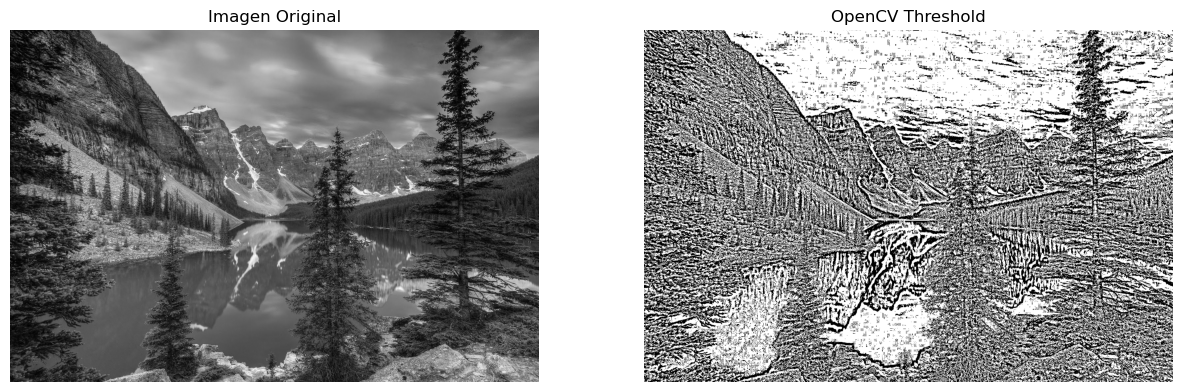

In [15]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen.jpg', 0)  # Escala de grises

ventana = 15
k = 2


imagen_fin = cv2.adaptiveThreshold(imagen, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, ventana, k)

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('OpenCV Threshold')
plt.imshow(imagen_fin, cmap='gray')
plt.axis('off')

plt.show()